# 03 – Narrative Volatility Index (NVI)


## 1. Introduction

Traditional GDELT-based studies primarily focus on:

- Conflict event prediction  
- Aggregated Goldstein scores  
- Event count–based risk indices  

However, these approaches largely ignore the **volatility of media narratives over time**.

To address this limitation, this study introduces the **Narrative Volatility Index (NVI)**.

Rather than measuring the absolute level of conflict, the NVI captures **how unstable a country's media narrative is within a rolling time window**.

This approach allows us to analyze narrative instability as a dynamic phenomenon emerging from changes in tone, systemic impact, and event structure.

## 2. Conceptual Framework

Narrative volatility may arise from multiple mechanisms within media systems.

Three dimensions are considered:

- **Affective volatility** — variation in media tone  
- **Systemic volatility** — changes in cooperation–conflict balance (Goldstein score)  
- **Structural volatility** — diversity of event types within narratives

These dimensions jointly capture how unstable the narrative environment of a country becomes over time.

## 3. Data Source

The analysis is based on **GDELT event data** stored in a DuckDB database.

The database contains several intermediate tables generated during the preprocessing pipeline. 
For the Narrative Volatility Index construction, we use the **`exports_clean`** table, which contains cleaned event-level records.

This table includes key variables such as:

- Event tone (`tone`)
- Goldstein score (`goldstein`)
- Event QuadClass (`quadclass`)
- Country identifiers
- Event timestamps

These cleaned event-level observations serve as the input for the subsequent country–month aggregation and volatility estimation steps.

In [1]:
import duckdb

# Connect to the DuckDB database
con = duckdb.connect("../data/intermediate/gdelt_main.db")

# Display all tables in the database
con.execute("SHOW TABLES").fetchdf()

,name
0,country_filter
1,exports_main
2,exports_main_clean
3,narrative_country_12month
4,narrative_country_clean
5,narrative_country_full
6,narrative_country_month
7,narrative_nvi
8,narrative_volatility
9,narrative_volatility_2025


In [2]:
# Preview the cleaned event table
con.execute("""
SELECT *
FROM exports_main_clean
LIMIT 5
""").fetchdf()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1218366341,20240102,202401,2024,2024.0055,NaN,NaN,Unknown,None,USA,...,2,"Maryland, United States",US,USMD,NaN,39.0724,-76.7902,MD,20250101000000,https://www.scotusblog.com/2024/12/in-year-end...
1,1218366342,20240102,202401,2024,2024.0055,NaN,NaN,Unknown,None,USA,...,2,"Maryland, United States",US,USMD,NaN,39.0724,-76.7902,MD,20250101000000,https://www.scotusblog.com/2024/12/in-year-end...
2,1218366343,20240102,202401,2024,2024.0055,CAN,CANADA,CAN,None,NaN,...,1,Canada,CA,CA,NaN,60.0000,-96,CA,20250101000000,https://www.castanetkamloops.net/news/BC/52531...
3,1218366344,20240102,202401,2024,2024.0055,USA,UNITED STATES,USA,None,GOV,...,3,"Smithfield, Virginia, United States",US,USVA,VA093,36.9824,-76.6311,1474779,20250101000000,https://www.nbcbayarea.com/news/national-inter...
4,1218366345,20240102,202401,2024,2024.0055,USA,ATLANTA,USA,None,MIL,...,3,"Atlanta, Georgia, United States",US,USGA,GA121,33.7490,-84.388,351615,20250101000000,https://www.fbherald.com/news/state/jimmy-and-...


## 4. Aggregation

Event-level observations are aggregated to the **country–month level**
to construct country-specific narrative indicators.

For each country and month, we compute:

- Total number of events (`event_count`)
- Mean and standard deviation of event tone (`tone_mean`, `tone_std`)
- Mean and standard deviation of Goldstein score (`goldstein_mean`, `goldstein_std`)
- Distribution of events across the four QuadClass categories (`quad1_ratio` – `quad4_ratio`)

Only observations with valid `Actor1CountryCode` values are included in the aggregation.

### 4.1 Create Country–Month Aggregation

In [3]:
con.execute("""
CREATE OR REPLACE TABLE narrative_country_month AS
SELECT
    DATE_TRUNC(
        'month',
        STRPTIME(CAST(Day AS VARCHAR), '%Y%m%d')
    ) AS year_month,

    Actor1CountryCode AS country,

    COUNT(*) AS event_count,

    AVG(AvgTone) AS tone_mean,
    STDDEV(AvgTone) AS tone_std,

    AVG(GoldsteinScale) AS goldstein_mean,
    STDDEV(GoldsteinScale) AS goldstein_std,

    SUM(CASE WHEN QuadClass = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad1_ratio,
    SUM(CASE WHEN QuadClass = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad2_ratio,
    SUM(CASE WHEN QuadClass = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad3_ratio,
    SUM(CASE WHEN QuadClass = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad4_ratio

FROM exports_main_clean
WHERE Actor1CountryCode IS NOT NULL
AND Actor1CountryCode != 'Unknown'

GROUP BY 1,2;
""")

### 4.2 Inspect Aggregated Data

To verify that the aggregation was performed correctly,
we preview the first rows of the `narrative_country_month` table.

In [4]:
con.execute("""
SELECT *
FROM narrative_country_month
ORDER BY country, year_month
LIMIT 20
""").fetchdf()

,year_month,country,event_count,tone_mean,tone_std,goldstein_mean,goldstein_std,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio
0,2024-01-01,ABW,1,-1.327014,NaN,1.000000,NaN,1.000000,0.000000,0.000000,0.000000
1,2024-03-01,ABW,1,-0.680272,NaN,3.400000,NaN,1.000000,0.000000,0.000000,0.000000
2,2024-05-01,ABW,1,5.248619,NaN,3.000000,NaN,1.000000,0.000000,0.000000,0.000000
3,2024-08-01,ABW,7,1.989606,1.168585,2.200000,1.249000,1.000000,0.000000,0.000000,0.000000
4,2025-01-01,ABW,88,1.808674,6.035664,0.463636,4.119904,0.693182,0.056818,0.068182,0.181818
5,2025-02-01,ABW,71,1.983232,2.416151,1.876056,2.862739,0.845070,0.056338,0.056338,0.042254
6,2025-03-01,ABW,122,-0.556585,4.042924,0.143443,4.155391,0.680328,0.065574,0.114754,0.139344
7,2025-04-01,ABW,80,-2.409526,5.844908,0.937500,3.590824,0.775000,0.012500,0.100000,0.112500
8,2025-05-01,ABW,109,-0.970551,4.835004,0.488991,4.128320,0.614679,0.082569,0.192661,0.110092
9,2025-06-01,ABW,37,-0.292545,5.834425,1.500000,2.493213,0.810811,0.000000,0.162162,0.027027


### 4.3 Create 12 Month Dataset

For the pilot study, we restrict the analysis to a
twelve-month window from **January 2025 to December 2025**.

In [5]:
con.execute("""
CREATE OR REPLACE TABLE narrative_country_12month AS
SELECT *
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31';
""")

### 4.4 Verify Dataset Dates

We confirm that the pilot dataset contains only the intended months.

In [6]:
con.execute("""
SELECT DISTINCT year_month
FROM narrative_country_12month
ORDER BY year_month
""").fetchdf()

,year_month
0,2025-01-01
1,2025-02-01
2,2025-03-01
3,2025-04-01
4,2025-05-01
5,2025-06-01
6,2025-07-01
7,2025-08-01
8,2025-09-01
9,2025-10-01


## 5. Structural Entropy

To capture narrative diversity, **Shannon entropy** is computed over the
QuadClass distribution.

     H = - Σ (p_i * log(p_i))

where \(p_i\) is the proportion of events in QuadClass \(i\) for a given
country–month.

**Interpretation**

- Low entropy → narrative concentrated in a single event type
- High entropy → heterogeneous event structure

Entropy serves as a proxy for **structural narrative fragmentation**
within national media narratives.

### 5.1 Add Entropy Column

In [7]:
# Add column for QuadClass entropy
con.execute("""
ALTER TABLE narrative_country_12month
ADD COLUMN quad_entropy DOUBLE;
""")

### 5.2 Compute Shannon Entropy

In [8]:
# Compute Shannon entropy for each row
con.execute("""
UPDATE narrative_country_12month
SET quad_entropy =
- (
    COALESCE(quad1_ratio * LN(NULLIF(quad1_ratio,0)), 0) +
    COALESCE(quad2_ratio * LN(NULLIF(quad2_ratio,0)), 0) +
    COALESCE(quad3_ratio * LN(NULLIF(quad3_ratio,0)), 0) +
    COALESCE(quad4_ratio * LN(NULLIF(quad4_ratio,0)), 0)
);
""")

### 5.3 Inspect Entropy Values

We preview the country–month observations with the highest entropy
values to examine highly heterogeneous narrative structures.

In [9]:
# Preview top 10 rows by entropy
con.execute("""
SELECT country, year_month,
       quad1_ratio, quad2_ratio, quad3_ratio, quad4_ratio,
       quad_entropy
FROM narrative_country_12month
ORDER BY quad_entropy DESC
LIMIT 10
""").fetchdf()

,country,year_month,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio,quad_entropy
0,HND,2025-12-01,0.386540,0.273224,0.153005,0.187230,1.322835
1,MLI,2025-01-01,0.454778,0.159556,0.198805,0.186860,1.285778
2,MLI,2025-08-01,0.417797,0.122881,0.172881,0.286441,1.283809
3,SWZ,2025-06-01,0.411765,0.117647,0.294118,0.176471,1.283173
4,VEN,2025-07-01,0.450176,0.200539,0.125751,0.223534,1.277144
5,BDI,2025-03-01,0.466495,0.164948,0.190722,0.177835,1.276081
6,PRK,2025-03-01,0.467258,0.167300,0.171525,0.193916,1.275141
7,SDN,2025-05-01,0.426553,0.115713,0.174178,0.283557,1.274768
8,SLV,2025-07-01,0.449172,0.161336,0.133352,0.256139,1.271358
9,GNQ,2025-09-01,0.467742,0.150538,0.209677,0.172043,1.270810


## 6. Volatility

Narrative volatility is estimated using a **rolling twelve-month window**.

For each country, we compute the rolling standard deviation of:

- Mean event tone (`tone_mean`)
- Mean Goldstein score (`goldstein_mean`)
- Structural entropy (`quad_entropy`)

The rolling window includes the **current month and the eleven preceding months**.

Volatility captures **dispersion in narrative signals rather than their absolute level**.

### 6.1 Compute Rolling Volatility

In [10]:
# Compute 12-month rolling volatility for tone, goldstein, and entropy
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_12month;
""")

### 6.2 Inspect Volatility Estimates

We preview the computed volatility values for each country–month
to ensure that the rolling window calculation behaves as expected.

In [11]:
con.execute("""
SELECT *
FROM narrative_volatility
ORDER BY country, year_month
LIMIT 12
""").fetchdf()

,country,year_month,tone_vol,goldstein_vol,entropy_vol
0,ABW,2025-01-01,NaN,NaN,NaN
1,ABW,2025-02-01,0.123431,0.998732,0.219195
2,ABW,2025-03-01,1.418661,0.921901,0.196330
3,ABW,2025-04-01,2.093611,0.754728,0.167371
4,ABW,2025-05-01,1.887981,0.673815,0.187147
5,ABW,2025-06-01,1.692087,0.670194,0.205230
6,ABW,2025-07-01,1.599156,0.719008,0.187373
7,ABW,2025-08-01,1.508134,0.758731,0.178891
8,ABW,2025-09-01,1.421845,0.743151,0.194077
9,ABW,2025-10-01,1.347916,0.700697,0.185020


## 7. NVI Construction

**Objective:** Compute a cross-sectional **Narrative Volatility Index (NVI)** for each country, based on the rolling volatilities computed in Section 6.

**Steps:**

1. **Select the final month** (`2025-12-01`) to focus on a snapshot of volatility.  
2. **Filter countries** to ensure sufficient data quality:  
   - Total events ≥ 60  
   - Minimum monthly events ≥ 10  
   - Non-null rolling volatilities (`tone_vol`, `goldstein_vol`, `entropy_vol`)  

3. **Compute z-scores** for each volatility component:

$$
z_x = \frac{x - \mu_x}{\sigma_x}
$$

where:  
- \(x\) is the volatility component (tone, Goldstein, or entropy)  
- \(\mu_x\) is the mean across countries  
- \(\sigma_x\) is the standard deviation across countries  

4. **Aggregate z-scores** into the composite NVI:

$$
\text{NVI} = z_{\text{tone\_vol}} + z_{\text{goldstein\_vol}} + z_{\text{entropy\_vol}}
$$

> Higher NVI values indicate greater narrative instability across countries.

### 7.1 SQL Implementation

In [12]:
# Select the final month for cross-sectional analysis
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_final AS
SELECT *
FROM narrative_volatility
WHERE year_month = DATE '2025-12-01';
""")

In [13]:
# Filter countries with sufficient events and valid volatilities
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_filtered AS
SELECT v.*
FROM narrative_volatility_final v
JOIN (
    SELECT country, SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_12month
    GROUP BY country
) e
ON v.country = e.country
WHERE e.total_events >= 60
  AND e.min_monthly_events >= 10
  AND tone_vol IS NOT NULL
  AND goldstein_vol IS NOT NULL
  AND entropy_vol IS NOT NULL;
""")

In [14]:
# Compute z-scores and final NVI
con.execute("""
CREATE OR REPLACE TABLE narrative_nvi AS
SELECT *,
       (tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) AS z_tone_vol,
       (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) AS z_goldstein_vol,
       (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0) AS z_entropy_vol,
       ((tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) +
        (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) +
        (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0)) AS NVI
FROM narrative_volatility_filtered;
""")

In [15]:
# Retrieve top 10 countries by NVI
df = con.execute("""
SELECT country, NVI, tone_vol, goldstein_vol, entropy_vol
FROM narrative_nvi
ORDER BY NVI DESC
""").fetchdf()

df.head(10)

,country,NVI,tone_vol,goldstein_vol,entropy_vol
0,SMR,10.865898,1.497805,2.101037,0.280370
1,BDI,9.185717,2.360198,1.280219,0.231667
2,GNB,9.053513,2.157619,0.978124,0.312452
3,COM,7.523160,1.869374,1.203827,0.222034
4,NRU,7.193067,1.446784,1.710278,0.160945
5,GNQ,6.774593,1.950108,1.088163,0.192316
6,EAF,6.631971,1.966114,1.115850,0.176655
7,TMP,6.481909,1.940335,1.096643,0.175687
8,AND,6.404837,1.447401,1.166274,0.225451
9,MDG,6.065862,2.024639,0.875602,0.184985


## 8. NVI Analysis

**Objective:** Analyze the cross-sectional NVI values to identify narrative instability patterns across countries.

**Steps:**

1. Visualize the **distribution** of NVI values across countries.
2. Identify **thresholds** for labeling regimes (`Stable`, `Low`, `Shock`).
3. Assign each country a **categorical regime label** based on its NVI.
4. Prepare the dataset for further clustering and comparison.

In [16]:
df['NVI'].quantile([0.25, 0.5, 0.75])

0.25   -1.711360
0.50   -0.591314
0.75    0.961895
Name: NVI, dtype: float64

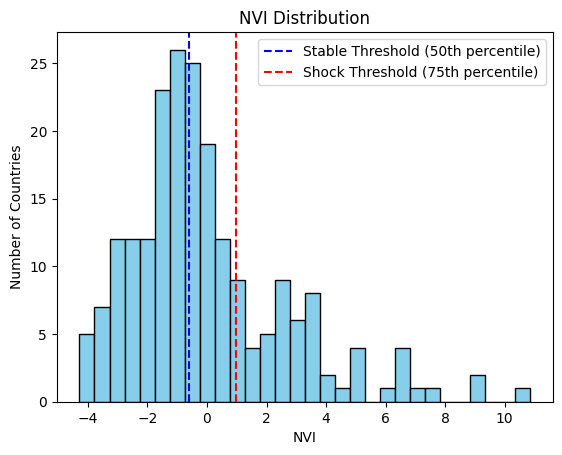

,country,NVI,nvi_label
0,SMR,10.865898,Shock
1,BDI,9.185717,Shock
2,GNB,9.053513,Shock
3,COM,7.523160,Shock
4,NRU,7.193067,Shock
5,GNQ,6.774593,Shock
6,EAF,6.631971,Shock
7,TMP,6.481909,Shock
8,AND,6.404837,Shock
9,MDG,6.065862,Shock


In [18]:
# Visualize NVI distribution
import matplotlib.pyplot as plt

# Compute quantiles once
q25 = df['NVI'].quantile(0.25)
q50 = df['NVI'].quantile(0.5)
q75 = df['NVI'].quantile(0.75)

# Histogram of NVI distribution
plt.hist(df['NVI'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(q50, color='blue', linestyle='--', label='Stable Threshold (50th percentile)')
plt.axvline(q75, color='red', linestyle='--', label='Shock Threshold (75th percentile)')
plt.title("NVI Distribution")
plt.xlabel("NVI")
plt.ylabel("Number of Countries")
plt.legend()
plt.show()

# Assign regime labels based on quantiles
def nvi_label(nvi):
    if nvi > q75:
        return 'Shock'
    elif nvi < q25:
        return 'Stable'
    else:
        return 'Moderate'

df['nvi_label'] = df['NVI'].apply(nvi_label)

# Preview labeled countries
df[['country','NVI','nvi_label']].sort_values('NVI', ascending=False).head(10)

## 9. Clustering

**Objective:** Perform unsupervised clustering on countries based on their narrative volatilities (`tone_vol`, `goldstein_vol`, `entropy_vol`) to identify discrete **narrative regimes**.

**Steps:**

1. **Select features** for clustering (without using NVI).  
2. **Standardize features** using `StandardScaler`.  
3. Apply **KMeans clustering** with 3 clusters.  
4. **Evaluate clustering** using the Silhouette score.  
5. Visualize clusters in **2D space** using PCA.  
6. Compute cluster-level averages and assign **regime labels** (`Stable`, `Low`, `Shock`) for interpretation.

Silhouette Score: 0.4187234073540818


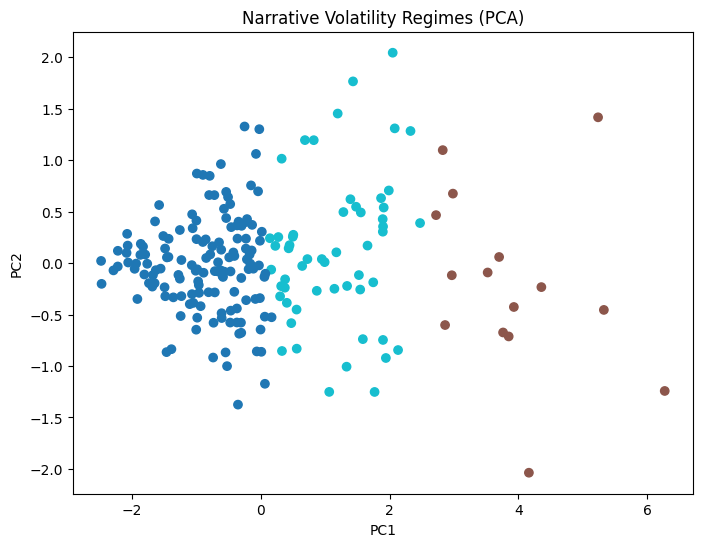

         tone_vol  goldstein_vol  entropy_vol  volatility_score
cluster                                                        
0        0.549138       0.366860     0.069446          0.985444
2        1.014802       0.664038     0.138941          1.817781
1        1.750553       1.127098     0.209699          3.087351
{0: 'Stable', 2: 'Moderate', 1: 'Shock'}


In [19]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features for clustering (exclude NVI)
X = df[['tone_vol','goldstein_vol','entropy_vol']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette Score:", score)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10')
plt.title("Narrative Volatility Regimes (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Cluster summary
cluster_summary = df.groupby('cluster')[['tone_vol','goldstein_vol','entropy_vol']].mean()
cluster_summary['volatility_score'] = cluster_summary.sum(axis=1)
cluster_summary = cluster_summary.sort_values('volatility_score')

# Map clusters to regime labels
labels = ["Stable","Moderate","Shock"]
cluster_label_map = {cluster: label for cluster, label in zip(cluster_summary.index, labels)}
df['kmeans_label'] = df['cluster'].map(cluster_label_map)

# Display cluster summary and label mapping
print(cluster_summary)
print(cluster_label_map)

In [20]:
# Shock kümesinin (Cluster 1) NVI alt sınırını bul
shock_min_nvi = df[df['kmeans_label'] == 'Shock']['NVI'].min()
print(f"Tespit edilen Şok Eşiği: {shock_min_nvi:.2f}")

# Moderate/Low kümesinin (Cluster 2) NVI alt sınırını bul
moderate_min_nvi = df[df['kmeans_label'] == 'Moderate']['NVI'].min()
print(f"Tespit edilen Moderate Eşiği: {moderate_min_nvi:.2f}")

cluster_nvi_mean = df.groupby('kmeans_label')['NVI'].mean().sort_values()
print(cluster_nvi_mean)

Tespit edilen Şok Eşiği: 4.70
Tespit edilen Moderate Eşiği: 0.25
kmeans_label
Stable     -1.488160
Moderate    1.979035
Shock       6.732245
Name: NVI, dtype: float64


## 9.1 Global Map of Narrative Regimes (KMeans)

**Objective:** Visualize the clustering results on a world map.

**Steps:**

1. Load country shapefile.  
2. Merge with `kmeans_label` from clustering.  
3. Assign colors to each regime:  
   - `Shock` → red  
   - `Stable` → blue  
   - `Low` → gray  
4. Plot countries with regime colors. Missing countries are light gray.

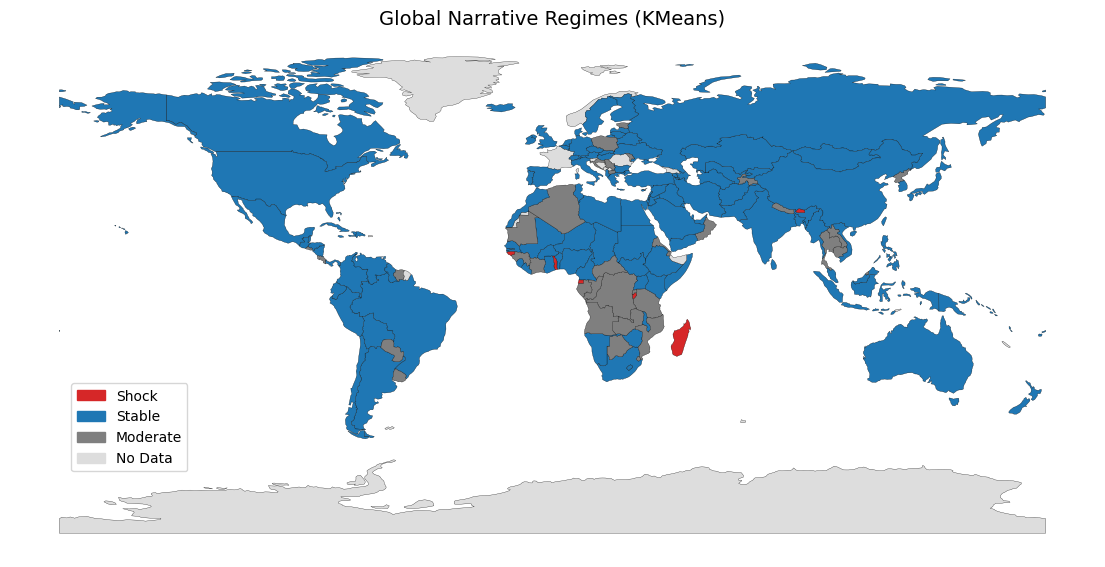

In [21]:
import geopandas as gpd
import zipfile
import tempfile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load country shapefile
zip_path = "../data/external/ne_110m_admin_0_countries.zip"
with zipfile.ZipFile(zip_path) as z:
    shp_file = [f for f in z.namelist() if f.endswith(".shp")][0]
    with tempfile.TemporaryDirectory() as tmpdir:
        z.extractall(tmpdir)
        world = gpd.read_file(f"{tmpdir}/{shp_file}")

# Rename ISO_A3 column for merging
world = world.rename(columns={"ISO_A3": "country"})

# Merge with clustering results
kmeans_map = world.merge(df[['country','kmeans_label']], on="country", how="left")

# Define color map
color_map_kmeans = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Moderate': "#7f7f7f"
}

# Legend for KMeans
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Moderate"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

kmeans_map["color"] = kmeans_map["kmeans_label"].map(color_map_kmeans).fillna("#dddddd")

# Plot map
fig, ax = plt.subplots(figsize=(14,8))
kmeans_map.plot(color=kmeans_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.set_title("Global Narrative Regimes (KMeans)", fontsize=14)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.axis("off")
plt.show()

## 9.2 Global Map of Narrative Volatility Index (NVI)

**Objective:** Compare clustering-based regimes with the continuous NVI measure.

**Steps:**

1. Assign discrete labels to countries based on NVI quantiles.  
2. Merge with world shapefile.  
3. Assign colors to NVI labels:
   - `Shock` → red  
   - `Stable` → blue  
   - `Low` → gray  
4. Plot countries with NVI regime colors. Missing countries are light gray.

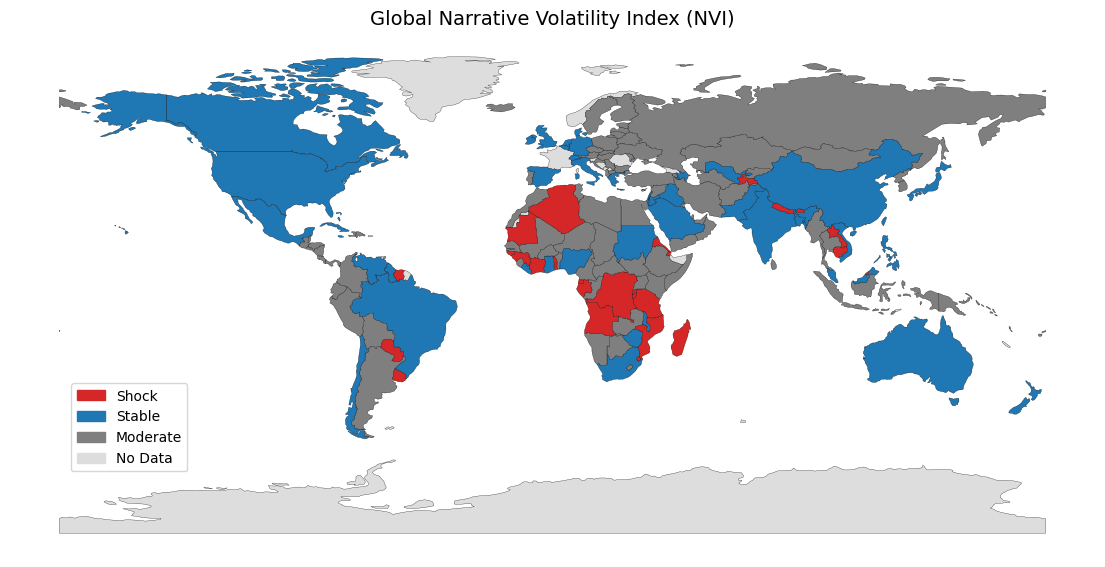

In [22]:
# Merge with world shapefile
nvi_map = world.merge(df[['country','nvi_label']], on="country", how="left")

color_map_nvi = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Moderate': "#7f7f7f"
}
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Moderate"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

nvi_map["color"] = nvi_map["nvi_label"].map(color_map_nvi).fillna("#dddddd")

# Plot NVI map
fig, ax = plt.subplots(figsize=(14,8))
nvi_map.plot(color=nvi_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.set_title("Global Narrative Volatility Index (NVI)", fontsize=14)
ax.axis("off")
plt.show()

### 9.3 Agreement Between KMeans and NVI Labels

In [23]:
# Compare KMeans labels with NVI labels
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
agreement_rate = comparison_df['same'].mean()

print("Agreement rate between KMeans and NVI labels:", agreement_rate)

# Show countries where labels differ
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)
diff_df.head(20)

Agreement rate between KMeans and NVI labels: 0.4028436018957346


,country,NVI,kmeans_label,nvi_label,same
15,KIR,4.298482,Moderate,Shock,False
16,MAC,4.034192,Moderate,Shock,False
17,RWA,3.666648,Moderate,Shock,False
18,FSM,3.615023,Moderate,Shock,False
19,CRB,3.583444,Moderate,Shock,False
20,PGS,3.457839,Moderate,Shock,False
21,DJI,3.358652,Moderate,Shock,False
22,MHL,3.299954,Moderate,Shock,False
23,ABW,3.298870,Moderate,Shock,False
24,PLW,3.292066,Moderate,Shock,False


## 10. Method Comparison

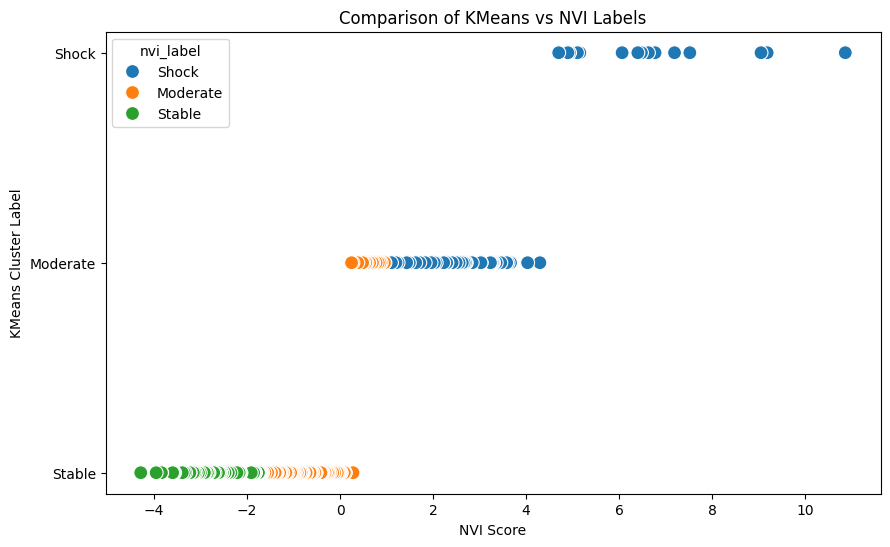

In [24]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=comparison_df, x='NVI', y='kmeans_label', hue='nvi_label', s=100)
plt.title("Comparison of KMeans vs NVI Labels")
plt.xlabel("NVI Score")
plt.ylabel("KMeans Cluster Label")
plt.show()

In [25]:
# Create comparison dataframe
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
# Check where labels match
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
# Compute overall agreement rate
agreement_rate = comparison_df['same'].mean()
print("Agreement rate between KMeans and NVI labels:", agreement_rate)

Agreement rate between KMeans and NVI labels: 0.4028436018957346


In [26]:
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)
diff_df.head(20)  # Top 20 differing cases

,country,NVI,kmeans_label,nvi_label,same
15,KIR,4.298482,Moderate,Shock,False
16,MAC,4.034192,Moderate,Shock,False
17,RWA,3.666648,Moderate,Shock,False
18,FSM,3.615023,Moderate,Shock,False
19,CRB,3.583444,Moderate,Shock,False
20,PGS,3.457839,Moderate,Shock,False
21,DJI,3.358652,Moderate,Shock,False
22,MHL,3.299954,Moderate,Shock,False
23,ABW,3.298870,Moderate,Shock,False
24,PLW,3.292066,Moderate,Shock,False


In [27]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(comparison_df['kmeans_label'], comparison_df['nvi_label'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.127698667891594


In [28]:
# Farklı olan ülkeler için detaylı tablo
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)

# Rolling volatility değerlerini de ekle
diff_df = diff_df.merge(
    df[['country','tone_vol','goldstein_vol','entropy_vol']],
    on='country',
    how='left'
)

# Top 20 farklı ülkeyi göster
diff_df.head(20)

,country,NVI,kmeans_label,nvi_label,same,tone_vol,goldstein_vol,entropy_vol
0,KIR,4.298482,Moderate,Shock,False,0.905110,1.022777,0.211595
1,MAC,4.034192,Moderate,Shock,False,1.171340,0.678435,0.228846
2,RWA,3.666648,Moderate,Shock,False,1.469756,0.909503,0.121207
3,FSM,3.615023,Moderate,Shock,False,1.033096,0.671981,0.225862
4,CRB,3.583444,Moderate,Shock,False,0.679096,0.683917,0.270511
5,PGS,3.457839,Moderate,Shock,False,0.884955,0.837265,0.204582
6,DJI,3.358652,Moderate,Shock,False,1.030225,1.080894,0.130476
7,MHL,3.299954,Moderate,Shock,False,0.695244,0.956498,0.198173
8,ABW,3.298870,Moderate,Shock,False,1.291174,0.657152,0.175661
9,PLW,3.292066,Moderate,Shock,False,0.904204,0.882790,0.183631


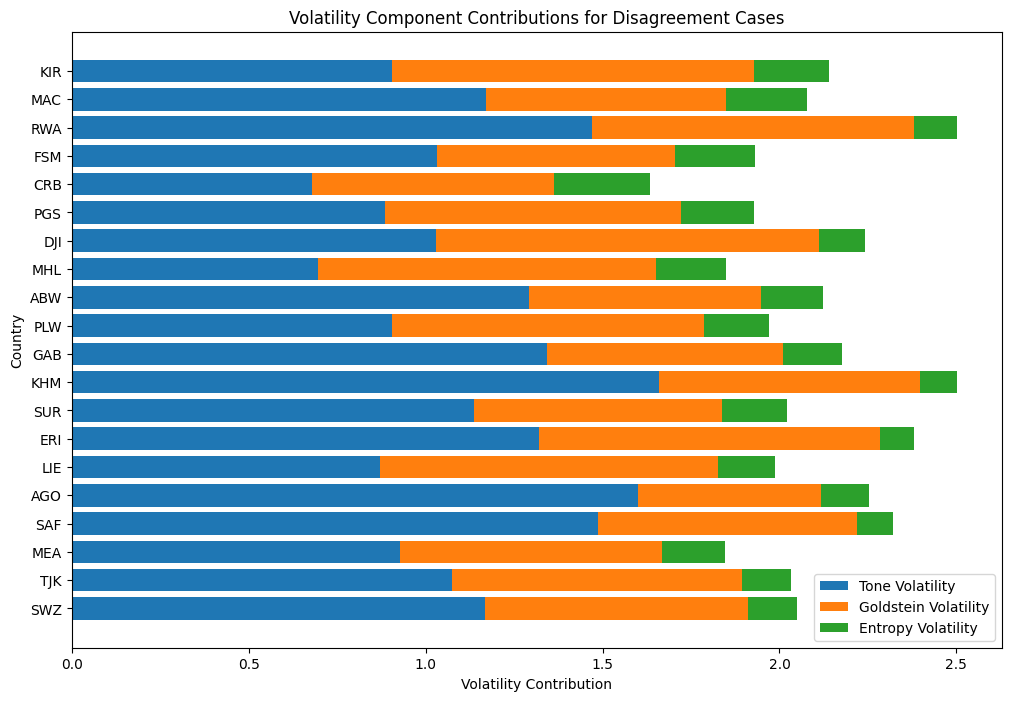

In [29]:
import matplotlib.pyplot as plt

# İlk 20 farklı ülkeyi al
plot_df = diff_df.head(20).copy()

# Ülkeleri NVI'ya göre sırala
plot_df = plot_df.sort_values("NVI", ascending=True)

plt.figure(figsize=(12,8))

plt.barh(plot_df['country'], plot_df['tone_vol'], label='Tone Volatility')
plt.barh(plot_df['country'], plot_df['goldstein_vol'], 
         left=plot_df['tone_vol'], label='Goldstein Volatility')

plt.barh(
    plot_df['country'],
    plot_df['entropy_vol'],
    left=plot_df['tone_vol'] + plot_df['goldstein_vol'],
    label='Entropy Volatility'
)

plt.xlabel("Volatility Contribution")
plt.ylabel("Country")
plt.title("Volatility Component Contributions for Disagreement Cases")
plt.legend()
plt.show()

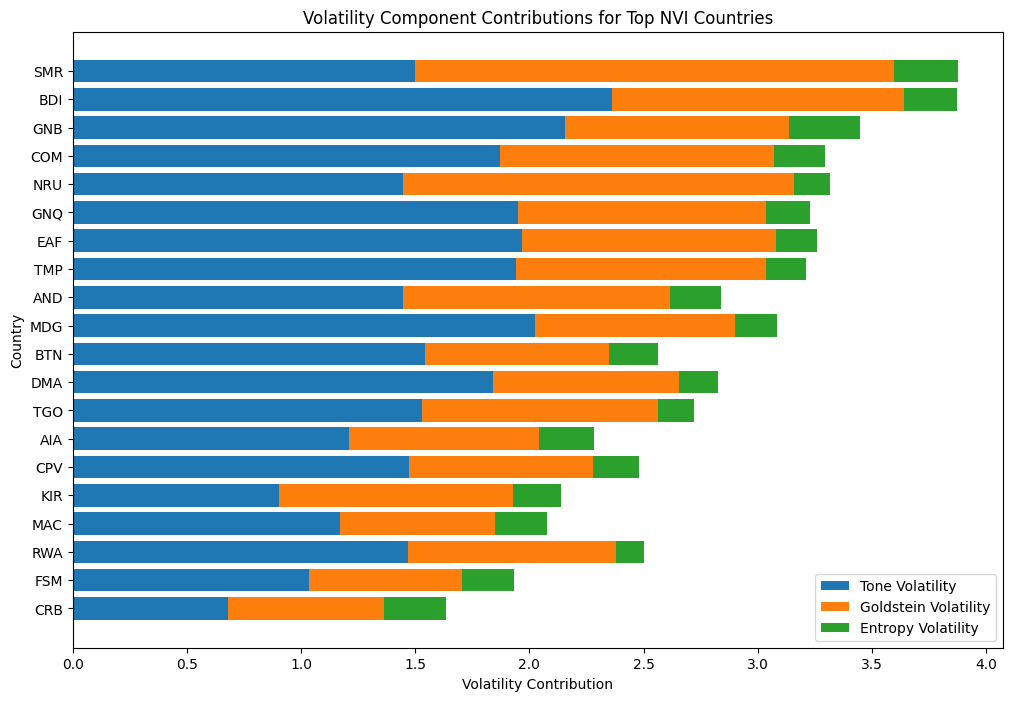

In [30]:
top_nvi_df = df.sort_values("NVI", ascending=False).head(20).copy()

import matplotlib.pyplot as plt

# NVI'ya göre sıralayalım
top_nvi_df = top_nvi_df.sort_values("NVI", ascending=True)

plt.figure(figsize=(12,8))

plt.barh(top_nvi_df['country'], top_nvi_df['tone_vol'], label='Tone Volatility')

plt.barh(
    top_nvi_df['country'],
    top_nvi_df['goldstein_vol'],
    left=top_nvi_df['tone_vol'],
    label='Goldstein Volatility'
)

plt.barh(
    top_nvi_df['country'],
    top_nvi_df['entropy_vol'],
    left=top_nvi_df['tone_vol'] + top_nvi_df['goldstein_vol'],
    label='Entropy Volatility'
)

plt.xlabel("Volatility Contribution")
plt.ylabel("Country")
plt.title("Volatility Component Contributions for Top NVI Countries")
plt.legend()

plt.show()

In [31]:
# NVI değeri 4.70 ve üzerinde olan (Şok rejimindeki) ülkeler
shock_countries = df[df['NVI'] >= 4.70].sort_values('NVI', ascending=False)

print(f"Toplam {len(shock_countries)} ülke 'Şok' rejiminde tespit edildi.\n")
print(shock_countries[['country', 'NVI', 'tone_vol', 'goldstein_vol', 'entropy_vol']].head(20))

Toplam 15 ülke 'Şok' rejiminde tespit edildi.

   country        NVI  tone_vol  goldstein_vol  entropy_vol
0      SMR  10.865898  1.497805       2.101037     0.280370
1      BDI   9.185717  2.360198       1.280219     0.231667
2      GNB   9.053513  2.157619       0.978124     0.312452
3      COM   7.523160  1.869374       1.203827     0.222034
4      NRU   7.193067  1.446784       1.710278     0.160945
5      GNQ   6.774593  1.950108       1.088163     0.192316
6      EAF   6.631971  1.966114       1.115850     0.176655
7      TMP   6.481909  1.940335       1.096643     0.175687
8      AND   6.404837  1.447401       1.166274     0.225451
9      MDG   6.065862  2.024639       0.875602     0.184985
10     BTN   5.156658  1.542994       0.803365     0.215175
11     DMA   5.106020  1.840196       0.816621     0.168757
12     TGO   4.935810  1.531677       1.030292     0.159209
13     AIA   4.901758  1.208991       0.833793     0.240957
14     CPV   4.702900  1.474065       0.806389     0.

In [32]:
# Tüm aylar için NVI hesaplayan sorgu
df_all_months = con.execute("""
WITH monthly_stats AS (
    SELECT 
        *,
        AVG(tone_vol) OVER (PARTITION BY year_month) as m_tone,
        STDDEV(tone_vol) OVER (PARTITION BY year_month) as s_tone,
        AVG(goldstein_vol) OVER (PARTITION BY year_month) as m_gold,
        STDDEV(goldstein_vol) OVER (PARTITION BY year_month) as s_gold,
        AVG(entropy_vol) OVER (PARTITION BY year_month) as m_entr,
        STDDEV(entropy_vol) OVER (PARTITION BY year_month) as s_entr
    FROM narrative_volatility
)
SELECT 
    country, 
    year_month,
    ((tone_vol - m_tone) / NULLIF(s_tone, 0) +
     (goldstein_vol - m_gold) / NULLIF(s_gold, 0) +
     (entropy_vol - m_entr) / NULLIF(s_entr, 0)) AS NVI
FROM monthly_stats
WHERE NVI IS NOT NULL
""").fetchdf()

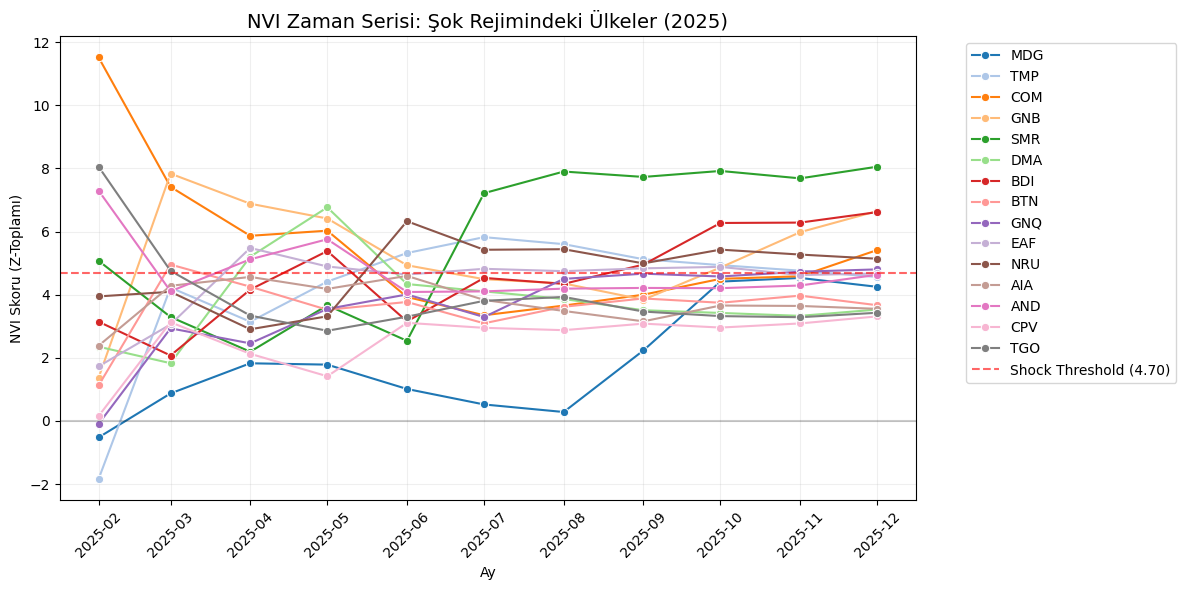

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Şok ülkelerinin listesi (Aralık ayında şokta olanlar)
shock_country_list = shock_countries['country'].tolist()

# Sadece bu ülkelerin 12 aylık verisini al
df_plot = df_all_months[df_all_months['country'].isin(shock_country_list)]

# Görselleştirme
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='year_month', y='NVI', hue='country', marker='o', palette='tab20')

# Şok eşiği (4.70)
plt.axhline(y=4.70, color='red', linestyle='--', alpha=0.6, label='Shock Threshold (4.70)')
# Ortalama hattı (0)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)

plt.title("NVI Zaman Serisi: Şok Rejimindeki Ülkeler (2025)", fontsize=14)
plt.ylabel("NVI Skoru (Z-Toplamı)")
plt.xlabel("Ay")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Aralık ayındaki NVI değerine göre en düşük (negatif) skora sahip 3 ülke
stable_countries = df.sort_values('NVI', ascending=True).head(3)
stable_country_list = stable_countries['country'].tolist()

print(f"En Stabil (Sakin) 3 Ülke: {stable_country_list}")
# Tahminimce bu ülkeler -3.0 ile -5.0 arasında NVI skoruna sahip olacak.

En Stabil (Sakin) 3 Ülke: ['GBR', 'USA', 'AFR']


In [35]:
print(q75)

0.9618946447475801


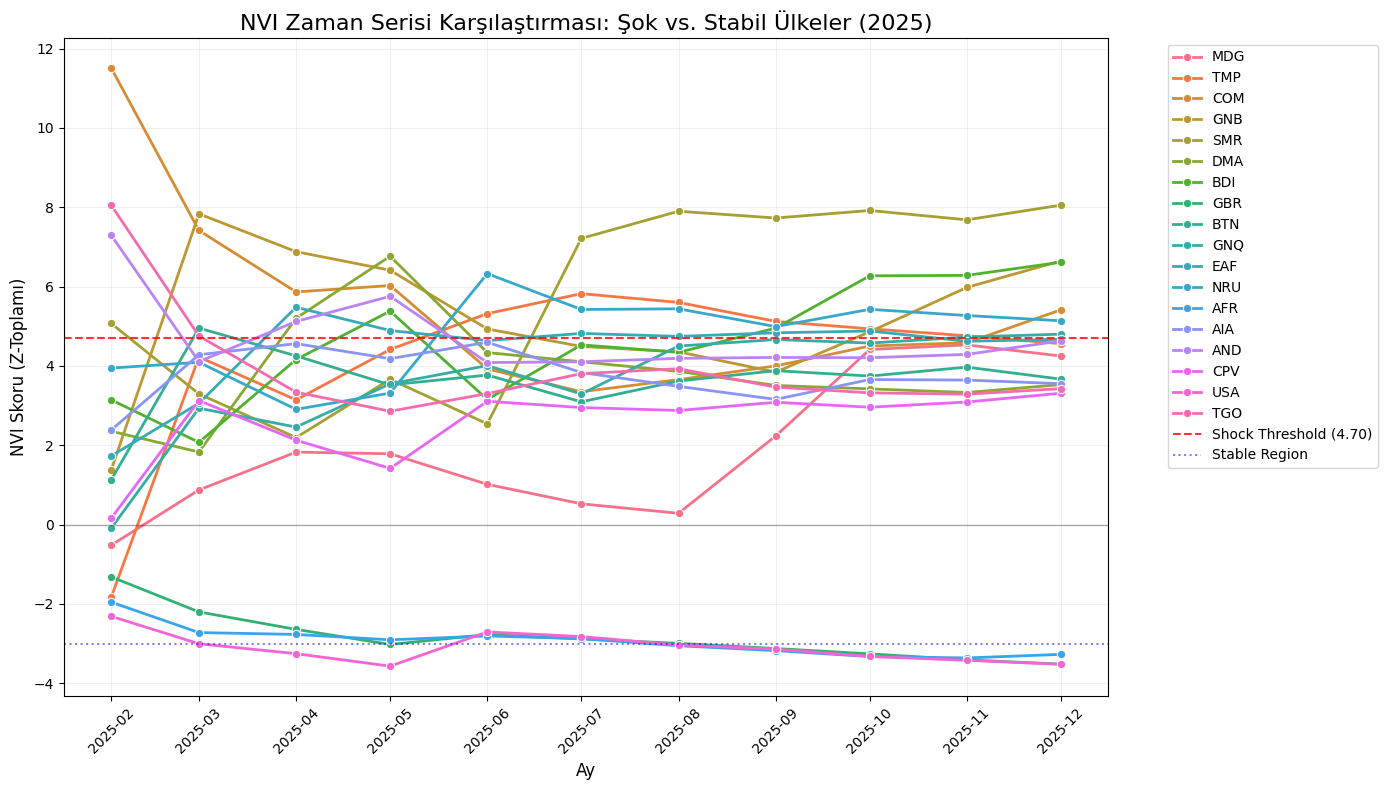

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# İki grup ülkeyi birleştir (Şok + Stabil)
combined_country_list = shock_country_list + stable_country_list

# Tüm 12 aylık veriden bu birleşik listeyi filtrele
df_plot_combined = df_all_months[df_all_months['country'].isin(combined_country_list)]

# Görselleştirme
plt.figure(figsize=(14, 8))
# palette='tab20' veya 'Set1' gibi farklı renk paletleri kullanılabilir
sns.lineplot(data=df_plot_combined, x='year_month', y='NVI', hue='country', marker='o', linewidth=2)

# --- Kritik Eşik Çizgileri ---
# Şok eşiği (4.70)
plt.axhline(y=4.70, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='Shock Threshold (4.70)')
# Stabilite/Ortalama Hattı (0)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
# Tahmini Stabilite Bölgesi (Örnek: -3.0) - Bu çizgiyi grafiği gördükten sonra ayarlayabiliriz
plt.axhline(y=-3.0, color='blue', linestyle=':', alpha=0.5, label='Stable Region')

# Grafiği güzelleştirme
plt.title("NVI Zaman Serisi Karşılaştırması: Şok vs. Stabil Ülkeler (2025)", fontsize=16)
plt.ylabel("NVI Skoru (Z-Toplamı)", fontsize=12)
plt.xlabel("Ay", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# İran ve İsrail verilerini çekelim
df_middle_east = df_all_months[df_all_months['country'].isin(['IRN', 'ISR'])]

# Bir de bu iki ülkenin 2025-12 (Aralık) son durumuna bakalım
df_me_final = df[(df['country'] == 'IRN') | (df['country'] == 'ISR')]

print("--- 2025-12 NVI Durumu ---")
print(df_me_final[['country', 'NVI', 'tone_vol', 'goldstein_vol', 'entropy_vol']])

--- 2025-12 NVI Durumu ---
    country       NVI  tone_vol  goldstein_vol  entropy_vol
146     IRN -1.395491  0.405539       0.499924     0.067865
180     ISR -2.531581  0.322818       0.477555     0.020513


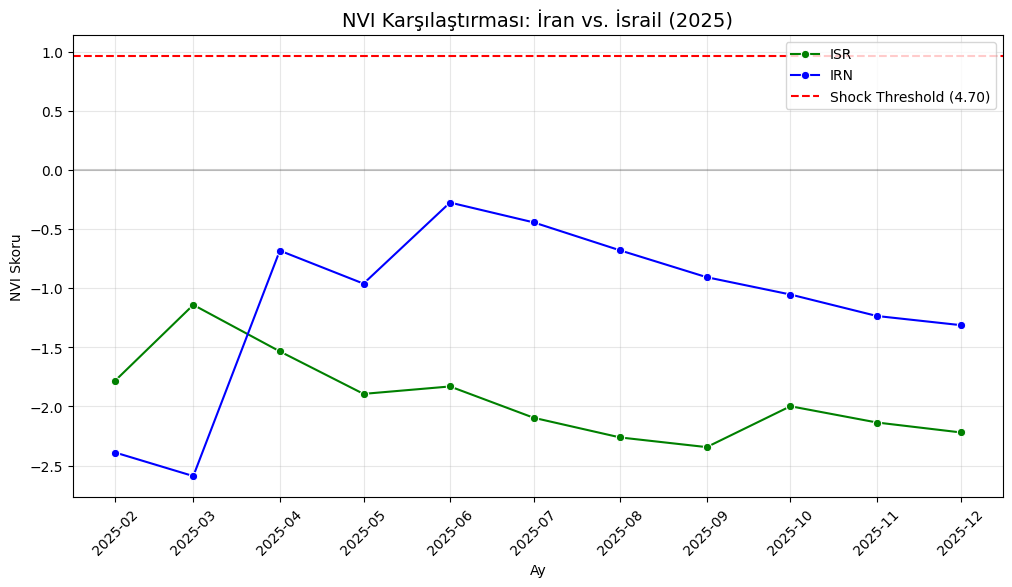

In [38]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_middle_east, x='year_month', y='NVI', hue='country', marker='o', palette=['green', 'blue'])

# Kritik Eşik Hattı
plt.axhline(y=q75, color='red', linestyle='--', label='Shock Threshold (4.70)')
plt.axhline(y=0, color='black', alpha=0.2)

plt.title("NVI Karşılaştırması: İran vs. İsrail (2025)", fontsize=14)
plt.ylabel("NVI Skoru")
plt.xlabel("Ay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

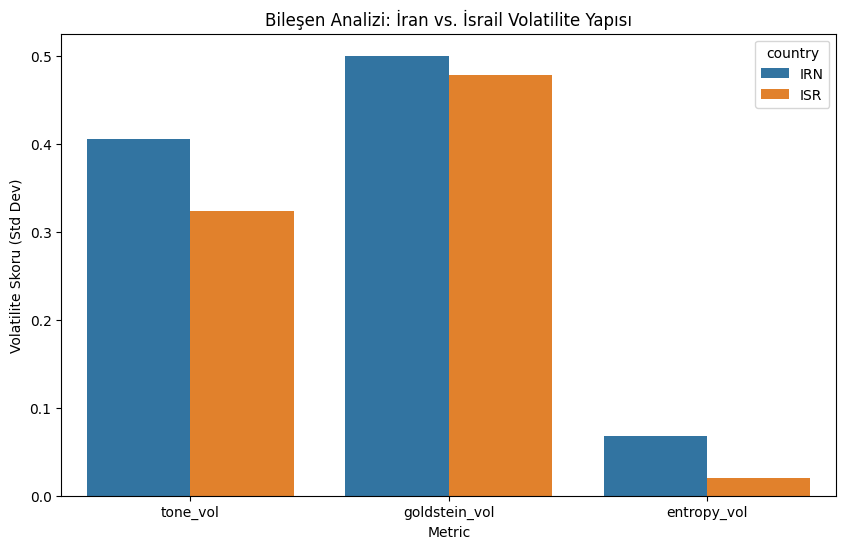

    country       NVI  tone_vol  goldstein_vol  entropy_vol
146     IRN -1.395491  0.405539       0.499924     0.067865
180     ISR -2.531581  0.322818       0.477555     0.020513


In [39]:
# İran ve İsrail'in bileşen bazlı karşılaştırması (Aralık 2025 verisi üzerinden)
me_comp = df[df['country'].isin(['IRN', 'ISR'])][['country', 'NVI', 'tone_vol', 'goldstein_vol', 'entropy_vol']]

# Görselleştirme için veriyi "melt" edelim (Bar plot için uygun hale getirelim)
me_melted = me_comp.melt(id_vars='country', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=me_melted[me_melted['Metric'] != 'NVI'], x='Metric', y='Value', hue='country')
plt.title("Bileşen Analizi: İran vs. İsrail Volatilite Yapısı")
plt.ylabel("Volatilite Skoru (Std Dev)")
plt.show()

print(me_comp)

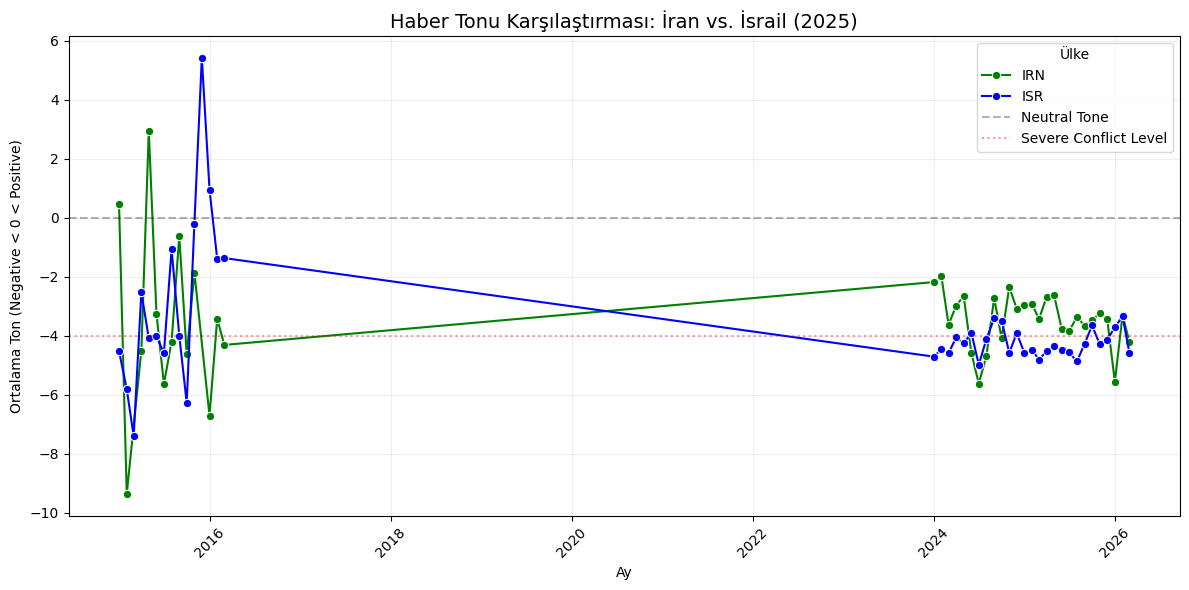

In [40]:
# 1. Tablodan sadece İran ve İsrail verilerini çekelim
df_me_tone = con.execute("""
    SELECT 
        country, 
        year_month, 
        tone_mean  -- Tablonuzdaki sütun adı 'tone_mean' veya 'avg_tone' olabilir, kontrol edin
    FROM narrative_country_month
    WHERE country IN ('IRN', 'ISR')
    ORDER BY year_month
""").fetchdf()

# 2. Zaman Serisi Görselleştirmesi
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_me_tone, x='year_month', y='tone_mean', hue='country', marker='o', palette=['green', 'blue'])

# Anlatı Dengesi Hattı (0 = Tamamen Nötr)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, label='Neutral Tone')

# Ortalama bir kriz eşiği (Genelde GDELT'te -4'ün altı çok sert çatışma demektir)
plt.axhline(y=-4, color='red', linestyle=':', alpha=0.4, label='Severe Conflict Level')

plt.title("Haber Tonu Karşılaştırması: İran vs. İsrail (2025)", fontsize=14)
plt.ylabel("Ortalama Ton (Negative < 0 < Positive)")
plt.xlabel("Ay")
plt.legend(title="Ülke")
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

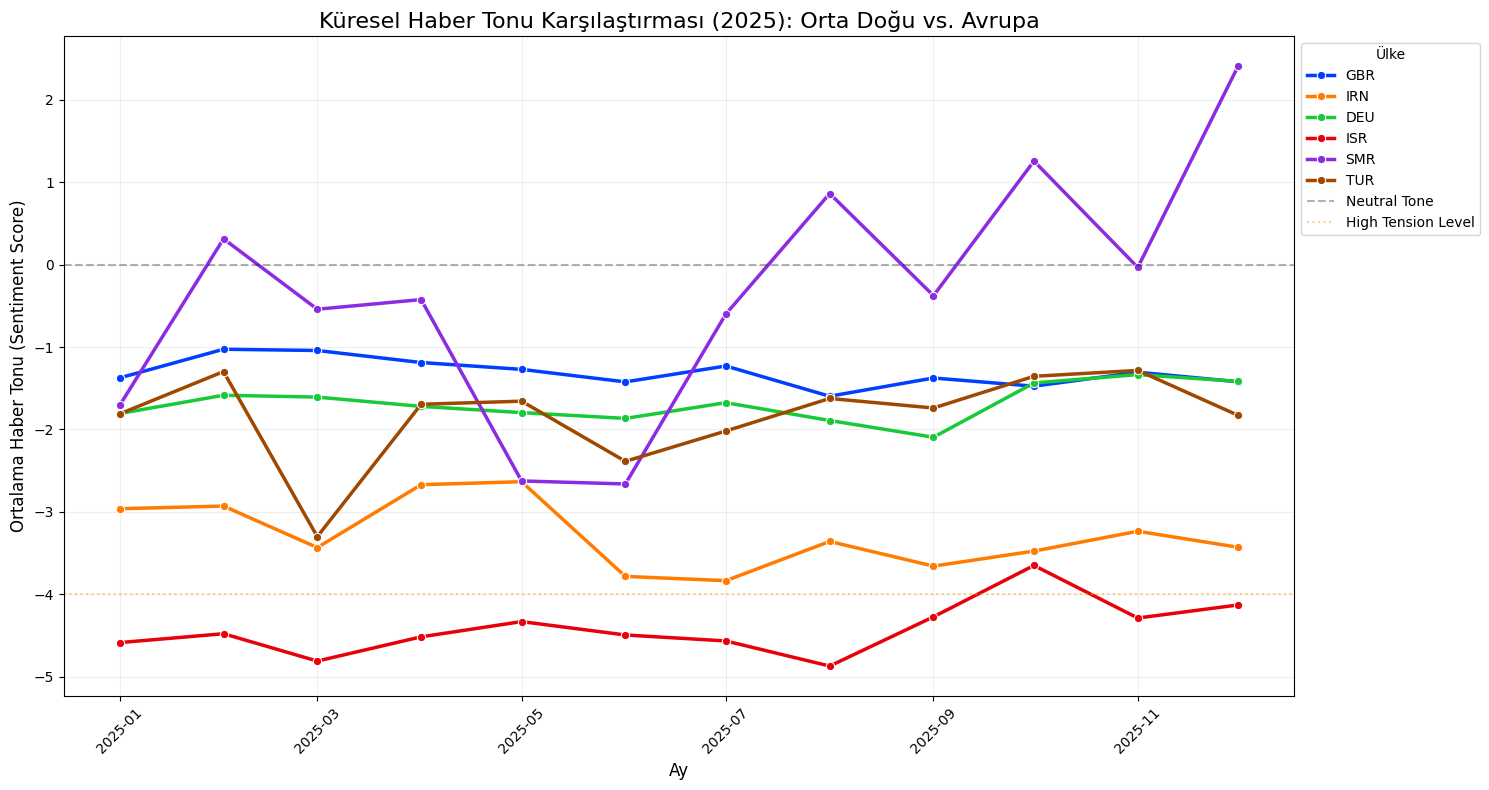

--- 2025 Yılı Ortalama Ton Karnesi ---
country
SMR   -0.343708
GBR   -1.310710
DEU   -1.685577
TUR   -1.833060
IRN   -3.283432
ISR   -4.415823
Name: tone_mean, dtype: float64


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sorguyu Güncelleme: 6 Ülke (Orta Doğu vs. Avrupa)
df_comparison = con.execute("""
    SELECT 
        country, 
        year_month, 
        tone_mean
    FROM narrative_country_12month
    WHERE country IN ('IRN', 'ISR', 'TUR', 'DEU', 'GBR', 'SMR')
    ORDER BY year_month
""").fetchdf()

# 2. Görselleştirme
plt.figure(figsize=(15, 8))

# 6 Ülke için net bir renk paleti (Set1 veya husl tercih edilebilir)
# IRN, ISR, TUR genellikle altlarda; DEU, GBR, FIN ise üstlerde kümelenecektir.
sns.lineplot(
    data=df_comparison, 
    x='year_month', 
    y='tone_mean', 
    hue='country', 
    marker='o', 
    palette='bright', # 6 farklı net renk için
    linewidth=2.5
)

# --- Referans Çizgileri ---
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, label='Neutral Tone')
plt.axhline(y=-4, color='orange', linestyle=':', alpha=0.5, label='High Tension Level')

# Grafik Ayarları
plt.title("Küresel Haber Tonu Karşılaştırması (2025): Orta Doğu vs. Avrupa", fontsize=16)
plt.ylabel("Ortalama Haber Tonu (Sentiment Score)", fontsize=12)
plt.xlabel("Ay", fontsize=12)
# Legend'ı grafiğin dışına alalım ki çizgiler kapanmasın
plt.legend(title="Ülke", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Ülke bazlı tüm yılın ortalamasını listeleyelim
print("--- 2025 Yılı Ortalama Ton Karnesi ---")
print(df_comparison.groupby('country')['tone_mean'].mean().sort_values(ascending=False))